# 📊 Assignment 1: Data Analysis, Visualization, and Feature Engineering
---
**Name:** Vahid Hamzeh

**Student ID:** 402101577

**Course:** Data Science / ADS 2026  

**Project Objective:**  
In this assignment, we take a raw dataset, perform the necessary preprocessing and cleaning, discover hidden patterns through visualization, and finally prepare the data for modeling using feature engineering and dimensionality reduction. The final section includes a bonus Web Scraping mini-project.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
import plotly.express as px
import json

def fix_fa(text):
    if pd.isna(text): return ""
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from arabic_reshaper import reshape
from bidi.algorithm import get_display

def f_text(text):
    if isinstance(text, str):
        return get_display(reshape(text))
    return text

df_full['group_fa'] = df_full['group'].apply(fix_fa)
if 'رنگ' in df_full.columns:
    df_full['color_fa'] = df_full['رنگ'].apply(fix_fa)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "Arial"  
plt.rcParams["axes.unicode_minus"] = False


## 🛠️ Part 1: Exploratory Data Analysis (EDA) & Data Cleaning
In this section, we import the required libraries and load the dataset. Through initial exploration, we identify and handle missing values and outliers to prepare a clean dataset.

**Key Steps:**
1. Examining data structure and variable types
2. Handling missing values (Imputation or Dropping)
3. Detecting and managing outliers


In [ ]:
with open('270_entities_dataset_v2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

def extract_entities(row):
    res = {}
    for item in row:
        res[item['name']] = item['values'][0] if item['values'] else np.nan
    return res

entities_df = df['entities'].apply(extract_entities).apply(pd.Series)

df_full = pd.concat([df.drop('entities', axis=1), entities_df], axis=1)

df_full.drop_duplicates(inplace=True)

categorical_cols = ['group', 'product', 'برند', 'رنگ', 'سایز']
for col in categorical_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna('نامشخص')

if 'group' in df_full.columns:
    df_full['group_fa'] = df_full['group'].apply(fix_fa)

if 'رنگ' in df_full.columns:
    df_full['color_fa'] = df_full['رنگ'].apply(fix_fa)

print(f"Data Shape after cleaning: {df_full.shape}")

print("Summary Statistics:\n", df_full.describe(include='all'))
print("\nMissing Values (%):\n", df_full.isna().mean() * 100)

print("\nTop 5 Groups:")
print(df_full['group'].value_counts().head())

if 'product' in df_full.columns:
    print("\nTop 5 Products:")
    print(df_full['product'].value_counts().head())

plt.figure(figsize=(10, 6))
numeric_df = df_full.select_dtypes(include=np.number)
if not numeric_df.empty:
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.title(fix_fa("نقشه همبستگی ویژگی‌های عددی"))
    plt.show()
else:
    print("No numeric columns for correlation heatmap.")


Data Shape after cleaning: (2835, 33)
Summary Statistics:
                                          title   group    product  \
count                                     2835    2835       2835   
unique                                    2697      32        658   
top     ست تیشرت شلوار راحتی مردانه برند هیراد  مردانه  ست پیژامه   
freq                                        12    2312        188   

                                  random_key  \
count                                   2835   
unique                                  2835   
top     052483d5-89f3-4b23-9cfb-4db723ec186b   
freq                                       1   

                                                image_url   brand  \
count                                                2835    2579   
unique                                               2820     510   
top     https://image.torob.com/base/images/eK/qI/eKqI...  نامشخص   
freq                                                    3    1117   

        

<Figure size 1000x600 with 0 Axes>

In [35]:
df_full['title_len'] = df_full['title'].apply(len)

df_full['word_count'] = df_full['title'].apply(lambda x: len(x.split()))

df_full['title_category'] = pd.cut(df_full['title_len'], bins=[0, 30, 60, 100], labels=['Short', 'Medium', 'Long'])

df_full['char_per_word'] = df_full['title_len'] / (df_full['word_count'] + 1)

df_full['title_group_combo'] = df_full['group'].astype(str) + '_' + df_full['title_category'].astype(str)

if 'date' in df_full.columns:
    df_full['year'] = pd.to_datetime(df_full['date']).dt.year
    df_full['month'] = pd.to_datetime(df_full['date']).dt.month
    df_full['day'] = pd.to_datetime(df_full['date']).dt.day

df_full['len_ratio'] = df_full['title_len'] / (df_full['char_per_word'] + 1)

print("Features Created: title_len, word_count, title_category, char_per_word")


Features Created: title_len, word_count, title_category, char_per_word


## 📈 Part 2: Data Visualization
To better understand the behavior of the variables and find correlations, we use various plots in this section. Visualization provides us with deeper insights into the dataset.

*This section includes pie charts, box plots (for distribution and outliers), line charts, bar charts, scatter plots, and bubble charts. We also utilized `Plotly` to create interactive visualizations.*


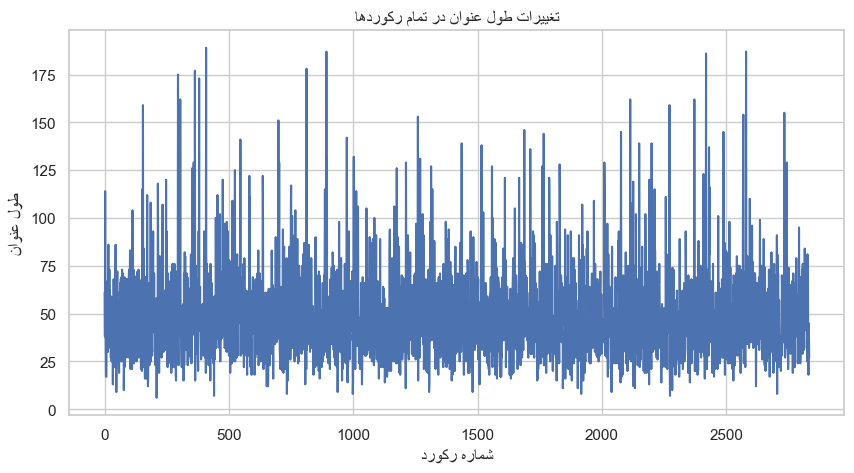

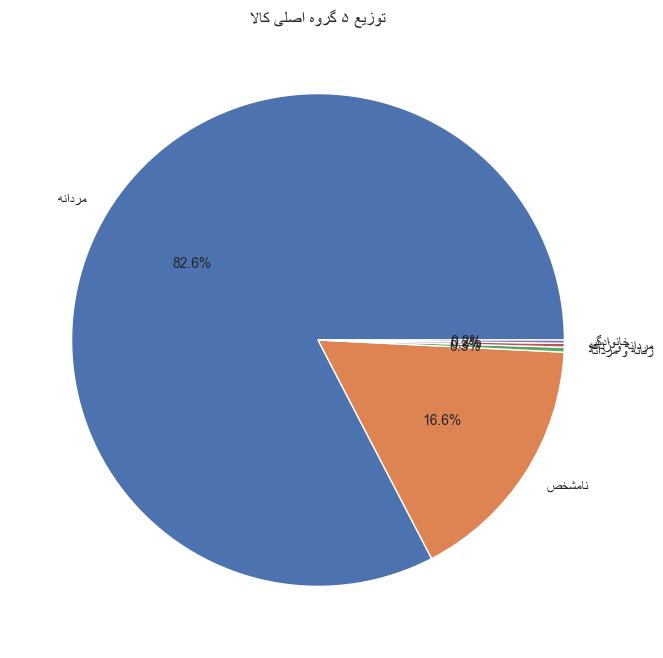

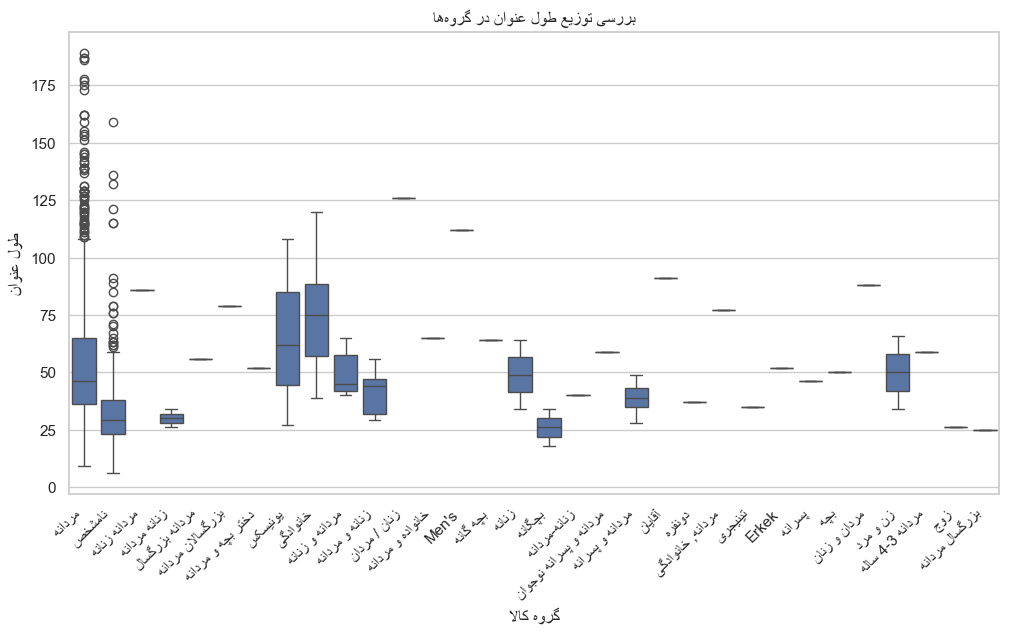

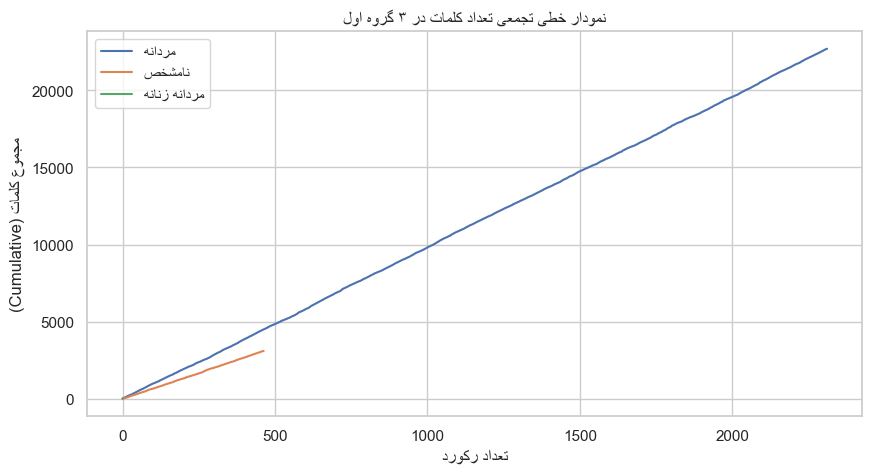

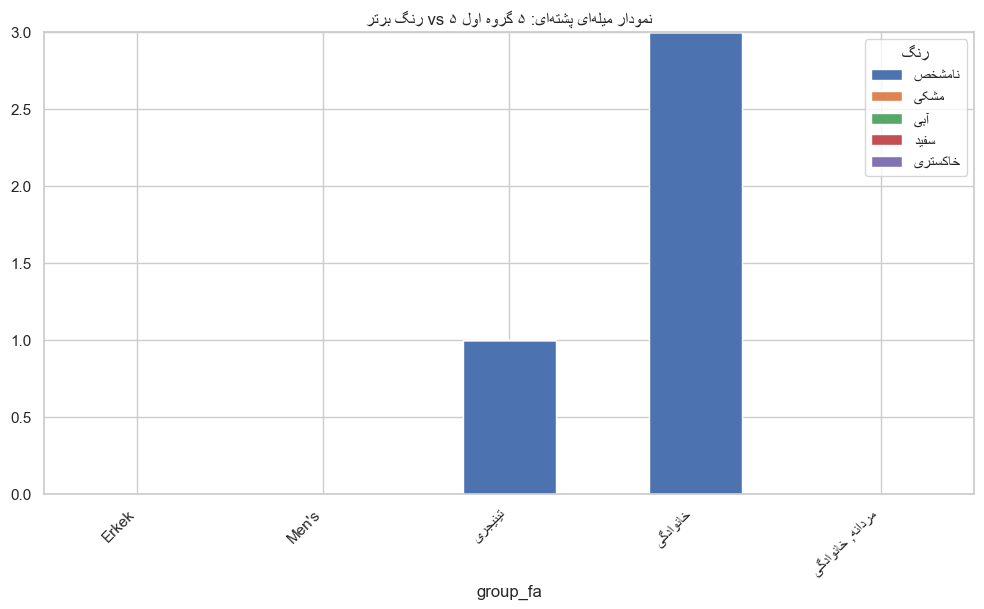

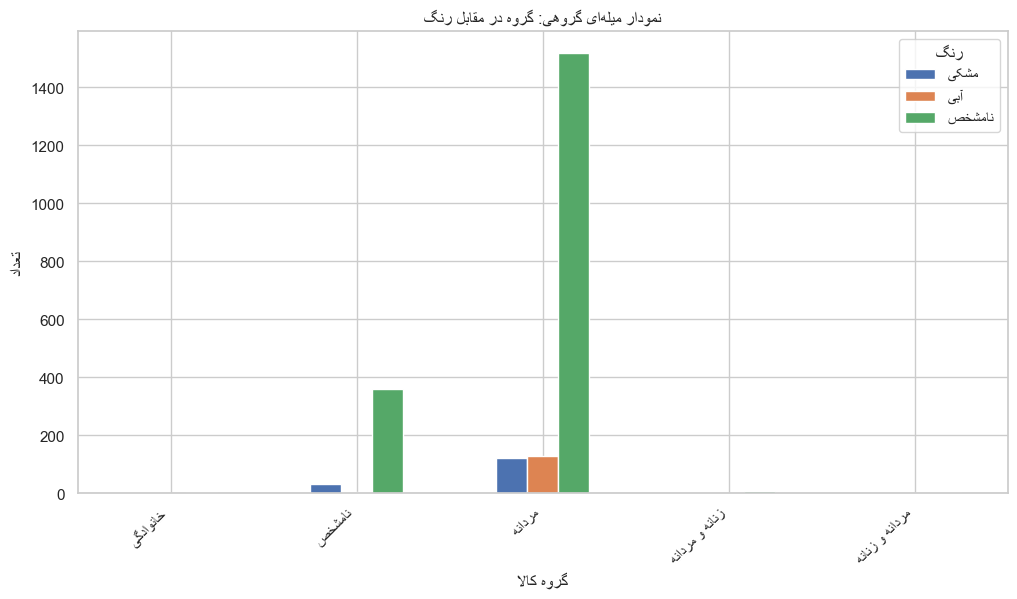

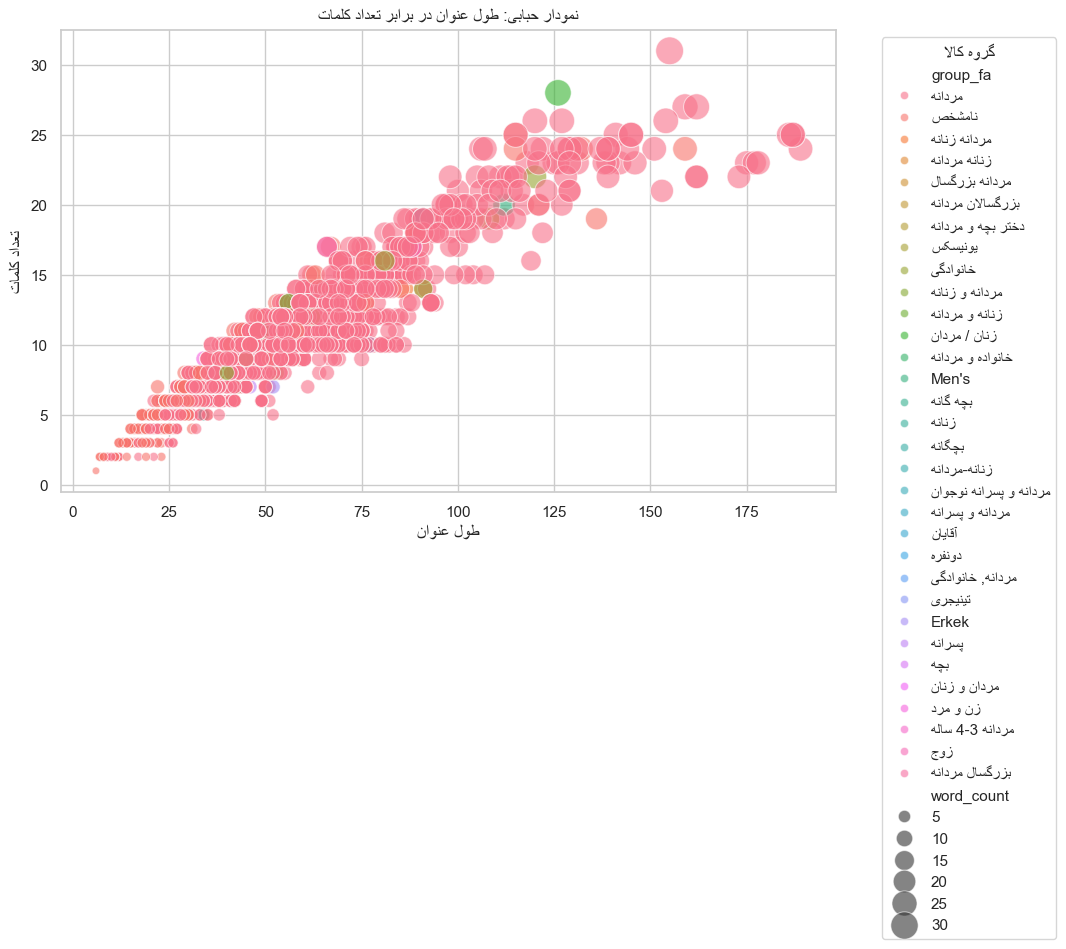

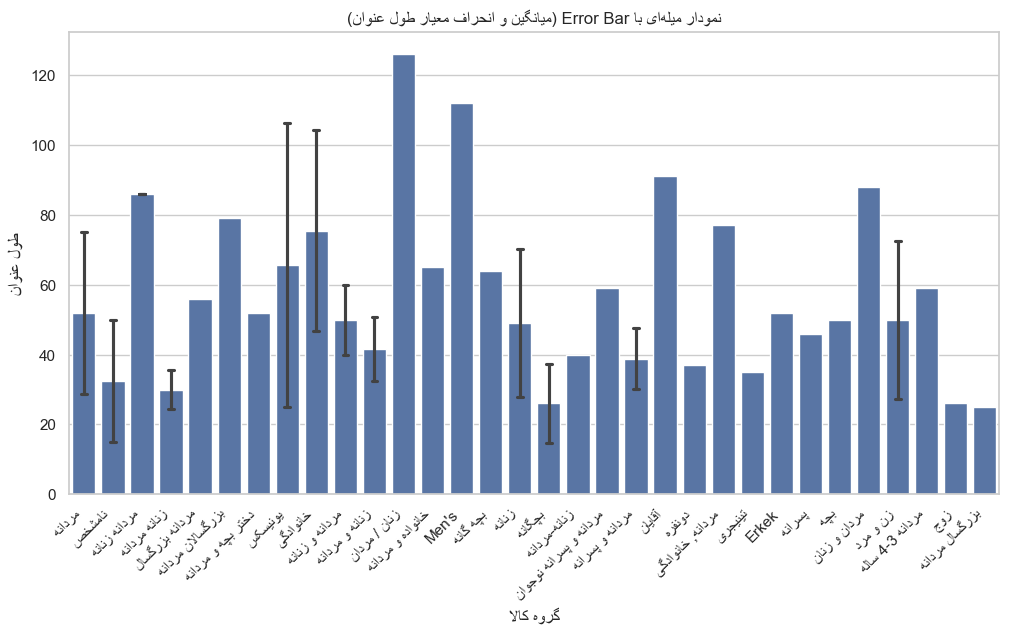

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df_full['title_len'].reset_index(drop=True))
plt.title(fix_fa("تغییرات طول عنوان در تمام رکوردها"))
plt.xlabel(fix_fa("شماره رکورد"))
plt.ylabel(fix_fa("طول عنوان"))
plt.show()

plt.figure(figsize=(8, 8))
top_groups = df_full['group_fa'].value_counts().head(5)
plt.pie(top_groups, labels=top_groups.index, autopct='%1.1f%%', textprops={'fontsize': 10})
plt.title(fix_fa("توزیع ۵ گروه اصلی کالا"))
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_full, x='group_fa', y='title_len')
plt.xticks(rotation=45, ha='right')
plt.title(fix_fa("بررسی توزیع طول عنوان در گروه‌ها"))
plt.xlabel(fix_fa("گروه کالا"))
plt.ylabel(fix_fa("طول عنوان"))
plt.show()

plt.figure(figsize=(10, 5))
for g in df_full['group_fa'].unique()[:3]:
    subset = df_full[df_full['group_fa'] == g].reset_index()
    plt.plot(subset.index, subset['word_count'].cumsum(), label=g)
plt.legend()
plt.title(fix_fa("نمودار خطی تجمعی تعداد کلمات در ۳ گروه اول"))
plt.xlabel(fix_fa("تعداد رکورد"))
plt.ylabel(fix_fa("مجموع کلمات (Cumulative)"))
plt.show()

if 'color_fa' in df_full.columns:
    top_colors = df_full['color_fa'].value_counts().head(5).index
    ct = pd.crosstab(df_full['group_fa'], df_full['color_fa'])[top_colors].head(5)
    ct.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.xticks(rotation=45, ha='right')
    plt.title(fix_fa("نمودار میله‌ای پشته‌ای: ۵ گروه اول vs ۵ رنگ برتر"))
    plt.legend(title=fix_fa("رنگ"))
    plt.show()

if 'color_fa' in df_full.columns:
    top5_groups = df_full['group_fa'].value_counts().head(5).index
    top5_colors = df_full['color_fa'].value_counts().head(3).index

    grouped_ct = df_full[df_full['group_fa'].isin(top5_groups) & df_full['color_fa'].isin(top5_colors)]
    grouped_ct = grouped_ct.groupby(['group_fa', 'color_fa']).size().unstack(fill_value=0)

    grouped_ct.plot(kind='bar', figsize=(12, 6))
    plt.xticks(rotation=45, ha='right')
    plt.title(fix_fa("نمودار میله‌ای گروهی: گروه در مقابل رنگ"))
    plt.xlabel(fix_fa("گروه کالا"))
    plt.ylabel(fix_fa("تعداد"))
    plt.legend(title=fix_fa("رنگ"))
    plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_full, 
    x='title_len', 
    y='word_count', 
    size='word_count',  
    hue='group_fa', 
    alpha=0.6, 
    sizes=(30, 400)
)
plt.title(fix_fa("نمودار حبابی: طول عنوان در برابر تعداد کلمات"))
plt.xlabel(fix_fa("طول عنوان"))
plt.ylabel(fix_fa("تعداد کلمات"))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title=fix_fa("گروه کالا"))
plt.show()


plt.figure(figsize=(12, 6))
sns.barplot(data=df_full, x='group_fa', y='title_len', capsize=.2, errorbar='sd')
plt.xticks(rotation=45, ha='right')
plt.title(fix_fa("نمودار میله‌ای با Error Bar (میانگین و انحراف معیار طول عنوان)"))
plt.xlabel(fix_fa("گروه کالا"))
plt.ylabel(fix_fa("طول عنوان"))
plt.show()

fig = px.scatter(df_full, x="title_len", y="word_count", color="group", 
                 hover_data=['product'], 
                 labels={"title_len": "طول عنوان", "word_count": "تعداد کلمات", "group": "گروه"},
                 title="نمودار تعاملی تحلیل کلمات (Plotly)")

fig.show()
fig.write_html("interactive_plot_analysis.html")

## ⚙️ Part 3: Feature Engineering
In this stage, we aim to enrich the dataset by extracting new features. We also reduce the dimensionality of the data to prevent future model complexity.

### 3.1. Feature Selection using Mutual Information
Using the Mutual Information method, we examine the dependency between various features and the target variable to select the most important ones.


In [ ]:
if existing_feature_columns and existing_target_column:
    X = df_encoded[existing_feature_columns]
    y = df_encoded[existing_target_column]
    
    X_scaled = scaler.fit_transform(X)
    
    from sklearn.feature_selection import mutual_info_regression
    mi = mutual_info_regression(X_scaled, y)
    
    mi_series = pd.Series(mi, index=existing_feature_columns)
    print("Mutual Information Scores:\n", mi_series.sort_values(ascending=False))

Mutual Information Scores:
 word_count       2.686082
char_per_word    1.543326
title_len        1.222637
product          0.424975
group            0.063666
dtype: float64


### 3.2. Dimensionality Reduction using PCA
Here, we apply **Principal Component Analysis (PCA)** to reduce the number of dimensions (features) while retaining the maximum variance in the data.


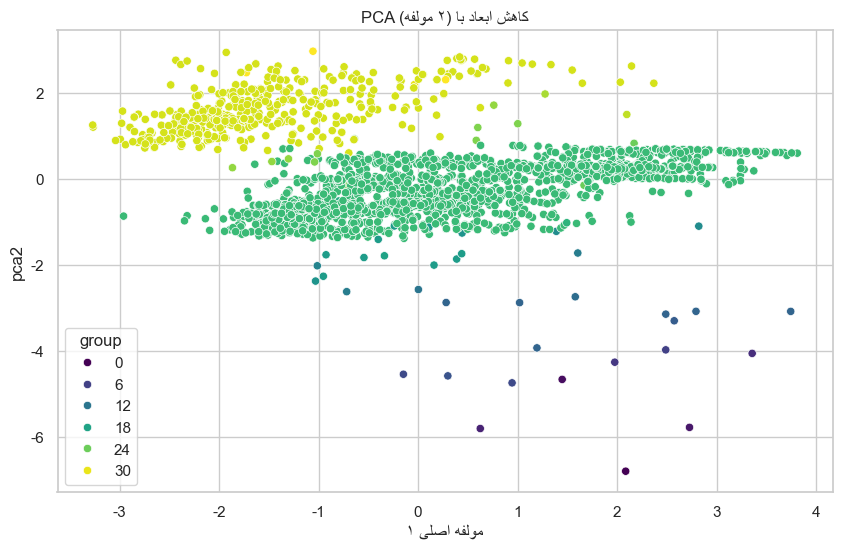

In [ ]:
if existing_feature_columns and existing_target_column:
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(X_scaled) 
    df_full['pca1'] = pca_res[:, 0]
    df_full['pca2'] = pca_res[:, 1]

    plt.figure(figsize=(10, 6))
    if 'group' in df_encoded.columns:
        sns.scatterplot(x=df_full['pca1'], y=df_full['pca2'], hue=df_encoded['group'], palette='viridis')
    else:
        sns.scatterplot(x=df_full['pca1'], y=df_full['pca2'], palette='viridis')
        
    plt.title(fix_fa("کاهش ابعاد با (۲ مولفه) PCA"))
    plt.xlabel(fix_fa("مولفه اصلی ۱"))
    # ... ادامه کدهای پلات


In [ ]:
df_full.to_csv("cleaned_dataset.csv", index=False, encoding="utf-8-sig")
print("Saved: cleaned_dataset.csv")

Saved: cleaned_dataset.csv


## Reflective Question: Feature Engineering – Nice-to-have or Must-have?

### When is feature engineering a *nice-to-have*?

Feature engineering is **nice-to-have** when:

- The dataset is already **well-structured** and **informative**.  
  For example, many classical machine learning benchmarks (like UCI datasets) already contain cleaned, aggregated, and meaningful features.
- The model is relatively **simple** and **interpretable**, and we only need a *baseline* performance.  
  In such cases, basic preprocessing (handling missing values, encoding categoricals, scaling) may be enough.
- The problem is not highly sensitive to small performance gains, e.g.:
  - Internal dashboards,
  - Simple reporting,
  - Educational / demo projects.
- We are in an **early exploration phase** and the goal is to quickly validate whether the signal exists in the data at all.  

In these situations, feature engineering can **improve performance** and interpretability, but the model is already usable without heavy feature crafting.

---

### When is feature engineering a *must-have*?

Feature engineering becomes **must-have** when:

- The **raw data does not directly expose the underlying patterns**.  
  For example:
  - Text data that needs token counts, TF–IDF, embeddings, or length-based features.
  - Transaction logs that need aggregation (e.g., total spend per user, frequency of purchases).
  - Time series where we need lags, rolling statistics, trends, or seasonality indicators.
- There is a strong need for **high performance** (accuracy, F1, AUC, etc.), such as:
  - Credit scoring,
  - Fraud detection,
  - Recommendation systems,
  - Industrial prediction systems.
- The model family is **sensitive to feature representation**, e.g.:
  - Linear models (logistic/linear regression),
  - Distance-based models (k-NN),
  - Some tree-based models when raw features are highly skewed or poorly scaled.
- We must incorporate **domain knowledge** explicitly:
  - Ratios (e.g., price per unit, conversions per visit),
  - Business rules (flags, risk scores),
  - Group-level aggregations (user-level, session-level, product-level stats).
- There are strong **interaction effects** between variables that are not captured unless we:
  - Create interaction terms (e.g., `feature_A * feature_B`),
  - Create non-linear transforms (log, square, binning).

In these cases, without feature engineering, the model:
- May completely miss critical relationships,
- May underperform significantly,
- Or may become misleading / unreliable in real-world use.

---

### Summary

- **Nice-to-have**:  
  When data is already rich and structured, stakes are low, and we only need a reasonable baseline.

- **Must-have**:  
  When raw data is noisy or unstructured, performance is critical, domain knowledge matters, or model quality heavily depends on how features are constructed.

In practice, serious machine learning projects almost always require **at least some level of feature engineering** to reach a production-grade model.


## 🕷️ Part 4 (Bonus): Web Scraping
In this standalone section, we extracted data for "Samand" car listings by calling the API of the **bama.ir** website. The collected data was then exported and saved as an Excel file (`.xlsx`) for future use.


In [42]:
import requests
import time
from typing import List, Dict, Any
import pandas as pd
from datetime import datetime


def normalize_price(ad_obj: Dict[str, Any]) -> str:
    """
    Extracts a human-readable price string from a raw ad JSON object.
    Tries several possible locations/fields in a slightly different order.
    Returns empty string if no valid price is found.
    """
    def _pick_from_price_dict(price_dict: Dict[str, Any]) -> str:
        if not isinstance(price_dict, dict):
            return ""

        # Different order نسبت به کد دوستت
        candidates = [
            price_dict.get("display_price"),
            price_dict.get("price_str"),
            price_dict.get("price"),
        ]
        for val in candidates:
            if val is None:
                continue
            s = str(val).strip()
            if s and s != "0":
                return s
        return ""

    top_price = ad_obj.get("price")
    result = _pick_from_price_dict(top_price) if top_price else ""

    if not result:
        detail_price = ad_obj.get("detail", {}).get("price")
        result = _pick_from_price_dict(detail_price) if detail_price else ""

    return result


def fetch_samand_ads(
    limit: int = 50,
    min_year: int = 1385,
    model_filter: str = "samand,lx",
    pause_sec: float = 0.5,
) -> List[Dict[str, Any]]:
    """
    Contacts bama.ir search API, iterates over pages, and returns a list of ads
    for Samand cars (or custom filter) with production year >= min_year.

    Each returned dict contains:
        - year
        - gearbox
        - mileage
        - main_color
        - price_text
        - description
    """
    endpoint = "https://bama.ir/cad/api/search"
    current_page = 1
    more_pages = True
    results: List[Dict[str, Any]] = []

    print(f"Requesting ads for '{model_filter}' with year >= {min_year} ...")

    while more_pages and len(results) < limit:
        query_params = {
            "vehicle": model_filter,
            "pageIndex": current_page,
        }

        try:
            resp = requests.get(endpoint, params=query_params, timeout=15)
            resp.raise_for_status()
        except requests.RequestException as ex:
            print(f"[ERROR] HTTP problem on page {current_page}: {ex}")
            break

        try:
            payload = resp.json()
        except ValueError as ex:
            print(f"[ERROR] JSON decode error on page {current_page}: {ex}")
            break

        if not payload.get("status", False):
            print(f"[ERROR] API returned status=False on page {current_page}: {payload.get('errors')}")
            break

        metadata = payload.get("metadata") or {}
        more_pages = bool(metadata.get("has_next", False))

        raw_ads = (payload.get("data") or {}).get("ads") or []
        if not raw_ads:
            print(f"[INFO] No ads returned for page {current_page}, stopping.")
            break

        for raw_ad in raw_ads:
            detail = raw_ad.get("detail") or {}

            year_raw = detail.get("year", "")
            try:
                year_val = int(str(year_raw).strip())
            except (TypeError, ValueError):
                continue

            if year_val < min_year:
                continue

            price_text = normalize_price(raw_ad)
            mileage_val = detail.get("mileage", "")
            color_raw = detail.get("color", "") or ""
            main_color = color_raw.split(" / ")[0].strip() if " / " in color_raw else color_raw.strip()
            gearbox_val = detail.get("transmission", "")
            desc_text = detail.get("description", "")

            record = {
                "ProductionYear": year_val,
                "Transmission": gearbox_val,
                "Mileage": mileage_val,
                "Color": main_color,
                "Price": price_text,
                "Description": desc_text,
            }
            results.append(record)

            if len(results) >= limit:
                break

        print(f"[INFO] Page {current_page} processed, collected so far: {len(results)}")
        current_page += 1
        time.sleep(pause_sec)

    print(f"[DONE] Total collected ads: {len(results)}")
    return results[:limit]


def export_to_excel(rows: List[Dict[str, Any]], filename: str | None = None) -> str:
    """
    Saves the list of dictionaries into an Excel file with specified or auto-generated name.
    Returns the final file path.
    """
    if not rows:
        raise ValueError("No rows to export.")

    df = pd.DataFrame(rows)

    columns_order = ["ProductionYear", "Transmission", "Mileage", "Color", "Price", "Description"]
    df = df.reindex(columns=columns_order)

    if filename is None:
        filename = "samand_dataset.xlsx"

    try:
        df.to_excel(filename, index=False, engine="openpyxl")
        print(f"[OK] Data saved to '{filename}'")
        return filename
    except PermissionError:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        fallback_name = f"samand_dataset_{ts}.xlsx"
        df.to_excel(fallback_name, index=False, engine="openpyxl")
        print(f"[OK] PermissionError on '{filename}', saved as '{fallback_name}' instead.")
        return fallback_name


if __name__ == "__main__":
    TARGET_ADS = 50
    MIN_YEAR = 1385

    ads_list = fetch_samand_ads(limit=TARGET_ADS, min_year=MIN_YEAR)

    if not ads_list:
        print("[WARN] No data collected. Check connectivity or filters.")
    else:
        path = export_to_excel(ads_list)
        print(f"[INFO] Finished. File: {path}")
        print("\nSample rows:")
        print(pd.DataFrame(ads_list).head())


Requesting ads for 'samand,lx' with year >= 1385 ...
[INFO] Page 1 processed, collected so far: 27
[INFO] Page 2 processed, collected so far: 50
[DONE] Total collected ads: 50
[OK] Data saved to 'samand_dataset.xlsx'
[INFO] Finished. File: samand_dataset.xlsx

Sample rows:
   ProductionYear Transmission     Mileage    Color        Price  \
0            1395      دنده ای  240,000 km     سفید  850,000,000   
1            1390      دنده ای  310,000 km  سرمه ای  650,000,000   
2            1385      دنده ای  300,000 km      مسی                
3            1386      دنده ای  200,000 km     سفید  500,000,000   
4            1391      دنده ای  344,000 km     سفید  635,000,000   

                                         Description  
0  رینگ اپیتیمایی \nشاسی ها سالم \nرنگ سه تیکه\nب...  
1  ماشین بسیار تمیز بوده فقط سمت شاگرد و کاپوت رن...  
2                                          تصادف عقب  
3  موتور تازه تعمیر گیربکس زانتیا تایرها۸۰درصد تم...  
4      خودروی دوگانه شرکتی موتور تازه تعمی